#  Modeling

In [1]:
import numpy as np
import pandas as pd
import re
import json
import joblib
import os
import pickle
import urllib.request
import zipfile
import nltk
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

# ── Shared cleaning function (keep identical to 02_preprocessing and streamlit_app) ──
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'reuters|21st century wire', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(tokens)

MAX_SEQ_LEN = 200

os.makedirs('../outputs/models',  exist_ok=True)
os.makedirs('../outputs/results', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Load data & split (70 / 15 / 15)

In [2]:
df = pd.read_csv('../data/processed/clean_data.csv').dropna(subset=['clean', 'label'])
print(f'Total rows: {len(df):,}')

X, y = df['clean'].values, df['label'].values

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print(f'Train {len(X_train):,} | Val {len(X_val):,} | Test {len(X_test):,}')

Total rows: 44,898
Train 31,428 | Val 6,735 | Test 6,735


## 2. Baseline — Logistic Regression with TF-IDF

Logistic Regression
               precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3523
        Real       0.99      0.99      0.99      3212

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



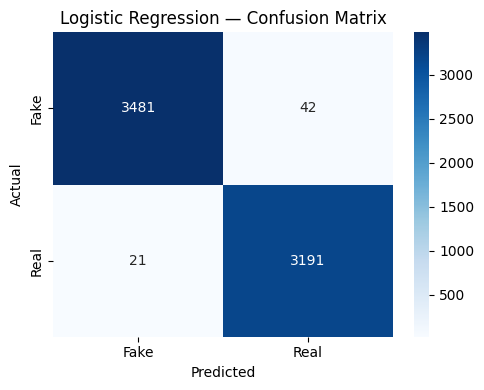

In [3]:
vectorizer = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

log_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
log_model.fit(X_train_tfidf, y_train)

log_pred = log_model.predict(X_test_tfidf)

log_metrics = {
    'accuracy':  float(accuracy_score(y_test, log_pred)),
    'precision': float(precision_score(y_test, log_pred)),
    'recall':    float(recall_score(y_test, log_pred)),
    'f1':        float(f1_score(y_test, log_pred)),
}
print('Logistic Regression\n', classification_report(
    y_test, log_pred, target_names=['Fake', 'Real']))

joblib.dump(log_model,  '../outputs/models/log_model.pkl')
joblib.dump(vectorizer, '../outputs/models/vectorizer.pkl')

# Confusion matrix
cm = confusion_matrix(y_test, log_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'], ax=ax)
ax.set_title('Logistic Regression — Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/results/log_confusion_matrix.png', dpi=150)
plt.show()

## 3. Vocabulary for LSTM

In [4]:
counter = Counter()
for text in X_train:
    counter.update(str(text).split())

vocab = {word: idx + 1
         for idx, (word, count) in enumerate(counter.items())
         if count >= 3}
print(f'Vocabulary size: {len(vocab):,}')

with open('../outputs/models/vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

Vocabulary size: 60,060


## 4. GloVe-100d pretrained embeddings

Downloads `glove.6B.zip` (~822 MB) on first run and caches it.
Subsequent runs skip the download.

In [5]:
GLOVE_DIR  = '../data/glove'
GLOVE_FILE = os.path.join(GLOVE_DIR, 'glove.6B.100d.txt')
GLOVE_URL  = 'https://nlp.stanford.edu/data/glove.6B.zip'
EMBED_DIM  = 100

os.makedirs(GLOVE_DIR, exist_ok=True)

if not os.path.exists(GLOVE_FILE):
    print('Downloading GloVe (~822 MB)...')
    zip_path = os.path.join(GLOVE_DIR, 'glove.6B.zip')
    urllib.request.urlretrieve(GLOVE_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(GLOVE_DIR)
    os.remove(zip_path)
    print('Done.')
else:
    print('GloVe already cached.')

# Build embedding matrix
glove = {}
with open(GLOVE_FILE, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)

VOCAB_SIZE = max(vocab.values()) + 1
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)
hits = 0
for word, idx in vocab.items():
    vec = glove.get(word)
    if vec is not None:
        embed_matrix[idx] = vec
        hits += 1

print(f'GloVe coverage: {hits:,}/{len(vocab):,} ({hits/len(vocab)*100:.1f}%)')

GloVe already cached.
GloVe coverage: 44,760/60,060 (74.5%)


## 5. Encode sequences

In [6]:
def encode(texts):
    result = []
    for text in texts:
        words = str(text).split()
        seq   = [vocab.get(w, 0) for w in words]
        seq   = seq[:MAX_SEQ_LEN] + [0] * (MAX_SEQ_LEN - len(seq))
        result.append(seq)
    return np.array(result, dtype=np.int64)

Xtr = encode(X_train)
Xvl = encode(X_val)
Xts = encode(X_test)
print('Shapes:', Xtr.shape, Xvl.shape, Xts.shape)

Shapes: (31428, 200) (6735, 200) (6735, 200)


## 6. LSTM model with GloVe embedding initialisation

In [7]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_matrix=None):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embed_matrix is not None:
            self.emb.weight.data.copy_(torch.from_numpy(embed_matrix))
        self.lstm = nn.LSTM(embed_dim, 128, num_layers=2,
                            batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc   = nn.Linear(128, 1)

    def forward(self, x):
        x = self.emb(x)
        _, (h, _) = self.lstm(x)
        return self.fc(self.dropout(h[-1]))

In [8]:
BATCH_SIZE = 128
EPOCHS     = 8
LR         = 1e-3

def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.tensor(X),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(Xtr, y_train)
val_loader   = make_loader(Xvl, y_val,  shuffle=False)
test_loader  = make_loader(Xts, y_test, shuffle=False)

model     = LSTMModel(VOCAB_SIZE, EMBED_DIM, embed_matrix).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=2, factor=0.5)

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)

            logits = model(xb).squeeze(1)
            probs = torch.sigmoid(logits)

            preds.extend((probs > 0.5).cpu().numpy().astype(int))
            labels.extend(yb.numpy().astype(int))

    return np.array(preds), np.array(labels)

best_val_acc = 0
history = {'train_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb.to(DEVICE)).squeeze(1), yb.to(DEVICE))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    val_preds, val_labels = evaluate(model, val_loader)
    val_acc  = accuracy_score(val_labels, val_preds)
    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "vocab": vocab,
            "vocab_size": VOCAB_SIZE,
            "embed_dim": EMBED_DIM}, 
            '../outputs/models/lstm_model.pth')

    print(f'Epoch {epoch}/{EPOCHS}  loss={avg_loss:.4f}  val_acc={val_acc:.4f}')

print(f'Best val accuracy: {best_val_acc:.4f}')

Epoch 1/8  loss=0.4635  val_acc=0.8371
Epoch 2/8  loss=0.3692  val_acc=0.9122
Epoch 3/8  loss=0.2172  val_acc=0.9549
Epoch 4/8  loss=0.1192  val_acc=0.9694
Epoch 5/8  loss=0.0639  val_acc=0.9791
Epoch 6/8  loss=0.0356  val_acc=0.9840
Epoch 7/8  loss=0.0216  val_acc=0.9850
Epoch 8/8  loss=0.0121  val_acc=0.9860
Best val accuracy: 0.9860


## 7. Training curve

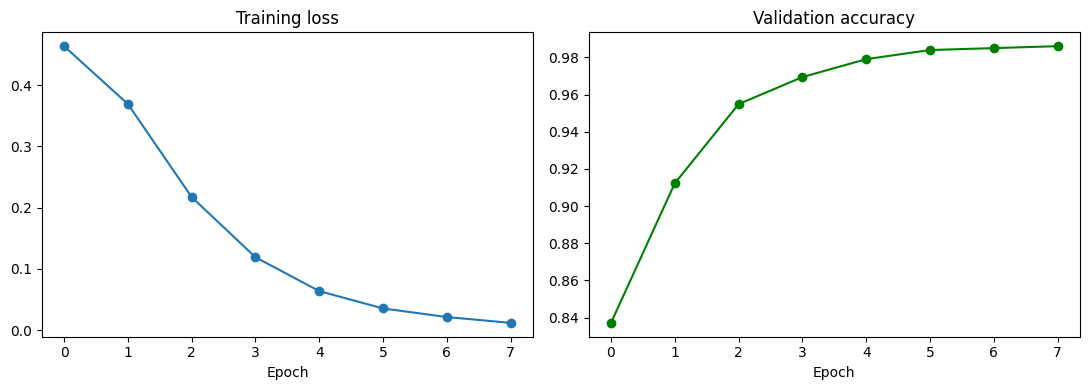

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['train_loss'], marker='o')
axes[0].set_title('Training loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(history['val_acc'], marker='o', color='green')
axes[1].set_title('Validation accuracy'); axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('../outputs/results/lstm_training_curve.png', dpi=150)
plt.show()

## 8. Final evaluation on held-out test set

LSTM
               precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3523
        Real       0.99      0.99      0.99      3212

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



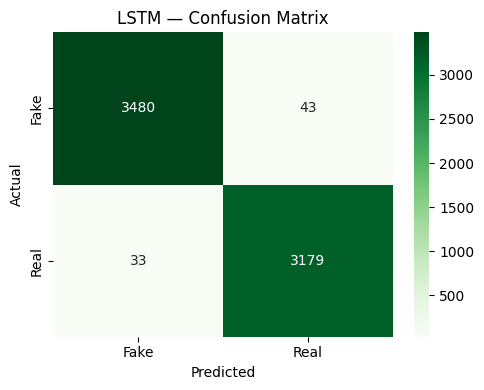

In [10]:
checkpoint = torch.load('../outputs/models/lstm_model.pth', map_location=DEVICE)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()

lstm_pred, _ = evaluate(model, test_loader)

lstm_metrics = {
    'accuracy':  float(accuracy_score(y_test, lstm_pred)),
    'precision': float(precision_score(y_test, lstm_pred)),
    'recall':    float(recall_score(y_test, lstm_pred)),
    'f1':        float(f1_score(y_test, lstm_pred)),
}

print('LSTM\n', classification_report(
    y_test, lstm_pred, target_names=['Fake', 'Real']))

cm_lstm = confusion_matrix(y_test, lstm_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            ax=ax)

ax.set_title('LSTM — Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../outputs/results/lstm_confusion_matrix.png', dpi=150)
plt.show()

## 9. Model comparison

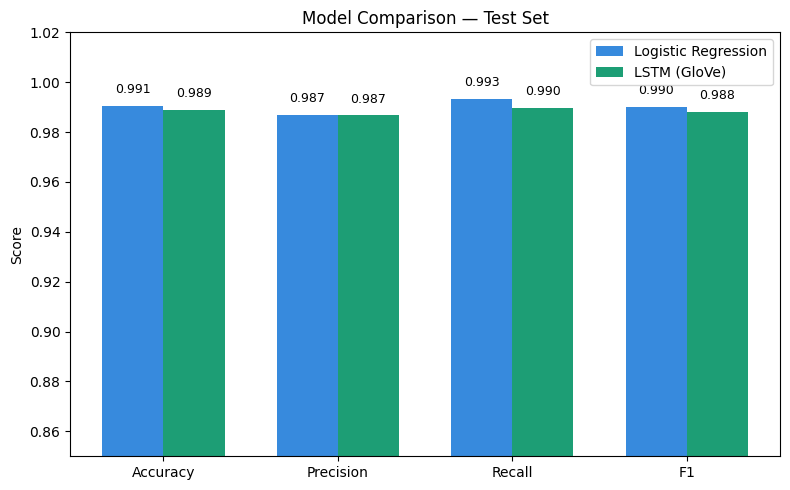


Summary
  logistic_regression        acc=0.9906  f1=0.9902
  lstm                       acc=0.9887  f1=0.9882


In [11]:
all_metrics = {
    'logistic_regression': log_metrics,
    'lstm': lstm_metrics,
}
with open('../outputs/results/all_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=4)
with open('../outputs/results/log_metrics.json',  'w') as f:
    json.dump(log_metrics, f, indent=4)
with open('../outputs/results/lstm_metrics.json', 'w') as f:
    json.dump(lstm_metrics, f, indent=4)

metric_names = ['accuracy', 'precision', 'recall', 'f1']
log_vals  = [log_metrics[m]  for m in metric_names]
lstm_vals = [lstm_metrics[m] for m in metric_names]
x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, log_vals,  width, label='Logistic Regression', color='#378ADD')
bars2 = ax.bar(x + width/2, lstm_vals, width, label='LSTM (GloVe)',        color='#1D9E75')
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0.85, 1.02)
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metric_names])
ax.set_title('Model Comparison — Test Set')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/results/model_comparison.png', dpi=150)
plt.show()

print('\nSummary')
for name, m in all_metrics.items():
    print(f"  {name:25s}  acc={m['accuracy']:.4f}  f1={m['f1']:.4f}")